# Bmad vs. Impact-Z for LCLS `cu_hxr`

NOTE: wakefields are disabled because they are not yet implemented in LUME-Impact

In [1]:
import impact.z as IZ
from pytao import Tao
from pmd_beamphysics import ParticleGroup
import matplotlib.pyplot as plt

# Bmad

In [2]:
TAO_INIT = '$LCLS_LATTICE/bmad/models/cu_hxr/tao.init'
LATTICE_FILE = '$LCLS_LATTICE/bmad/examples/bmad_vs_impactz/cu_hxr_no_superpositions.lat.bmad'
TRACK_START = 'OTR2'
#TRACK_END = 'ENDBC1'
TRACK_END = 'BEGUNDH'

IMPACT_TRACK_START = TRACK_START

# TODO: sc_hxr
#TAO_INIT = '$LCLS_LATTICE/bmad/models/sc_sxr/tao.init'
#TRACK_START = 'BEAM0'
#TRACK_END = 'CC32BEND'
#IMPACT_TRACK_START = 'MIRLHD'

tao = Tao(init_file=TAO_INIT, slice_lattice=f'{TRACK_START}:{TRACK_END}', plot='mpl', lattice_file=LATTICE_FILE)
tao.cmd(f'set beam track_start = {TRACK_START}')
tao.cmd(f'set beam track_end = {TRACK_END}')
tao.cmd('set beam beam_saved_at = marker::*')

tao.cmd('set bmad_com sr_wakes_on = F') # Not yet implemented in the Impact-Z conversion

tao.cmd('set beam_init n_particle = 1000') # Faster tracking

[]

In [3]:
%%time
tao.track_beam()

<!-- lume-impact detected Jupyter and will use HTML for rendering. -->

  0%|          | 0/1612 [00:00<?, ?ele/s]

CPU times: user 2.23 s, sys: 187 ms, total: 2.42 s
Wall time: 958 ms


['',
 'Tao: set global track_type = beam',
 '',
 'Tao: set global track_type = single']

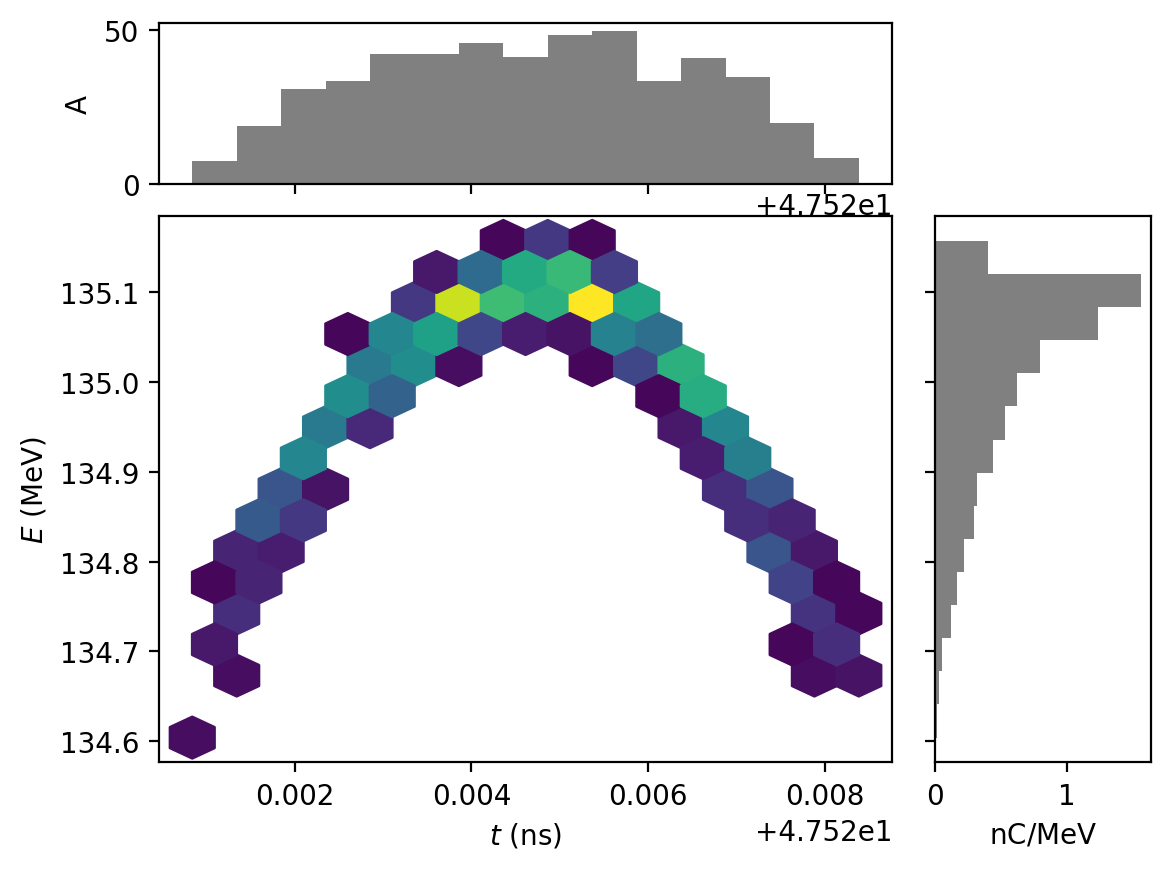

In [4]:
P0 = ParticleGroup(data = tao.bunch_data(IMPACT_TRACK_START))
#P0 = P0.resample(1000)
P0.plot('t', 'energy')

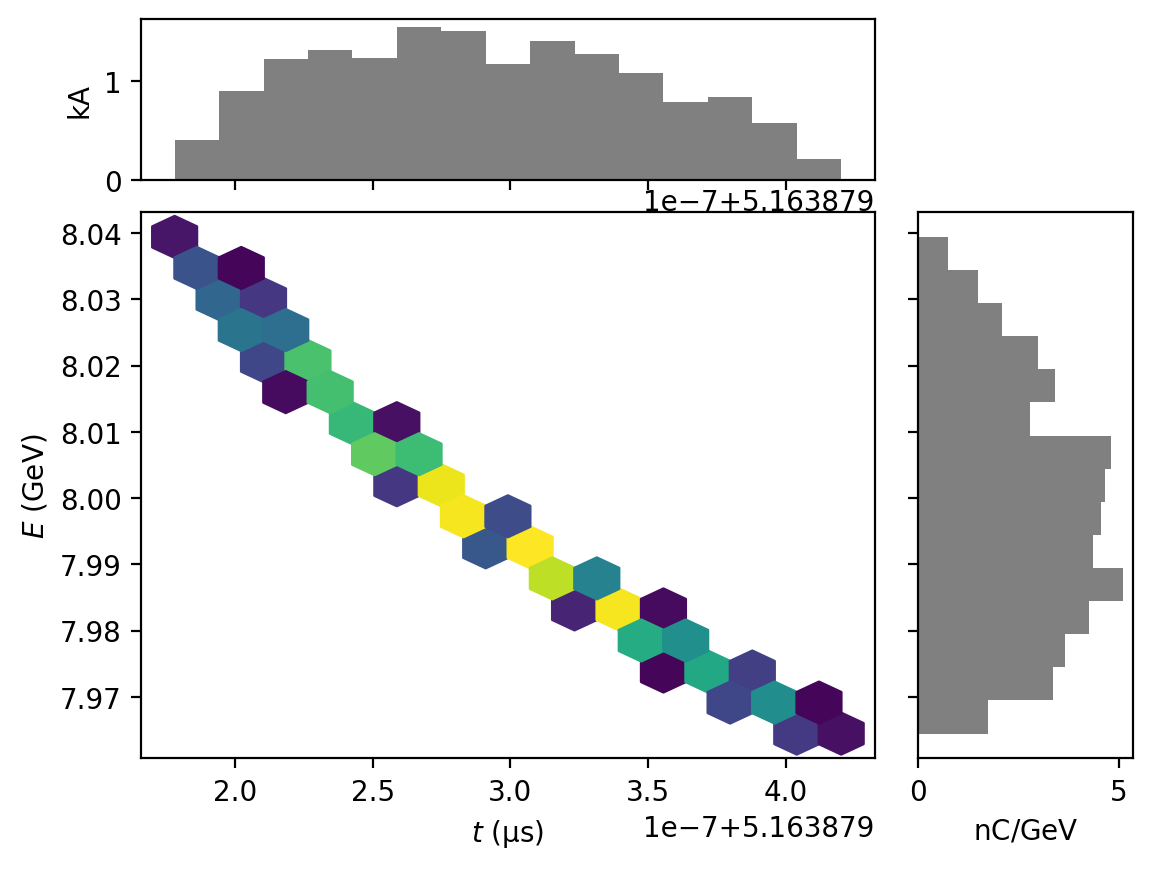

In [5]:
P1 = ParticleGroup(data = tao.bunch_data(TRACK_END))
P1.plot('t', 'energy')

# Impact-Z

This will make an Impact-Z lattice from the 

In [6]:
I = IZ.ImpactZ.from_tao(tao, track_start=IMPACT_TRACK_START, track_end=TRACK_END, write_beam_eles=(TRACK_END,))

In [7]:
I.initial_particles = P0
I.nproc = 1

In [8]:
%%time
output = I.run()

<!-- lume-impact detected Jupyter and will use HTML for rendering. -->

  0%|          | 0/1464 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



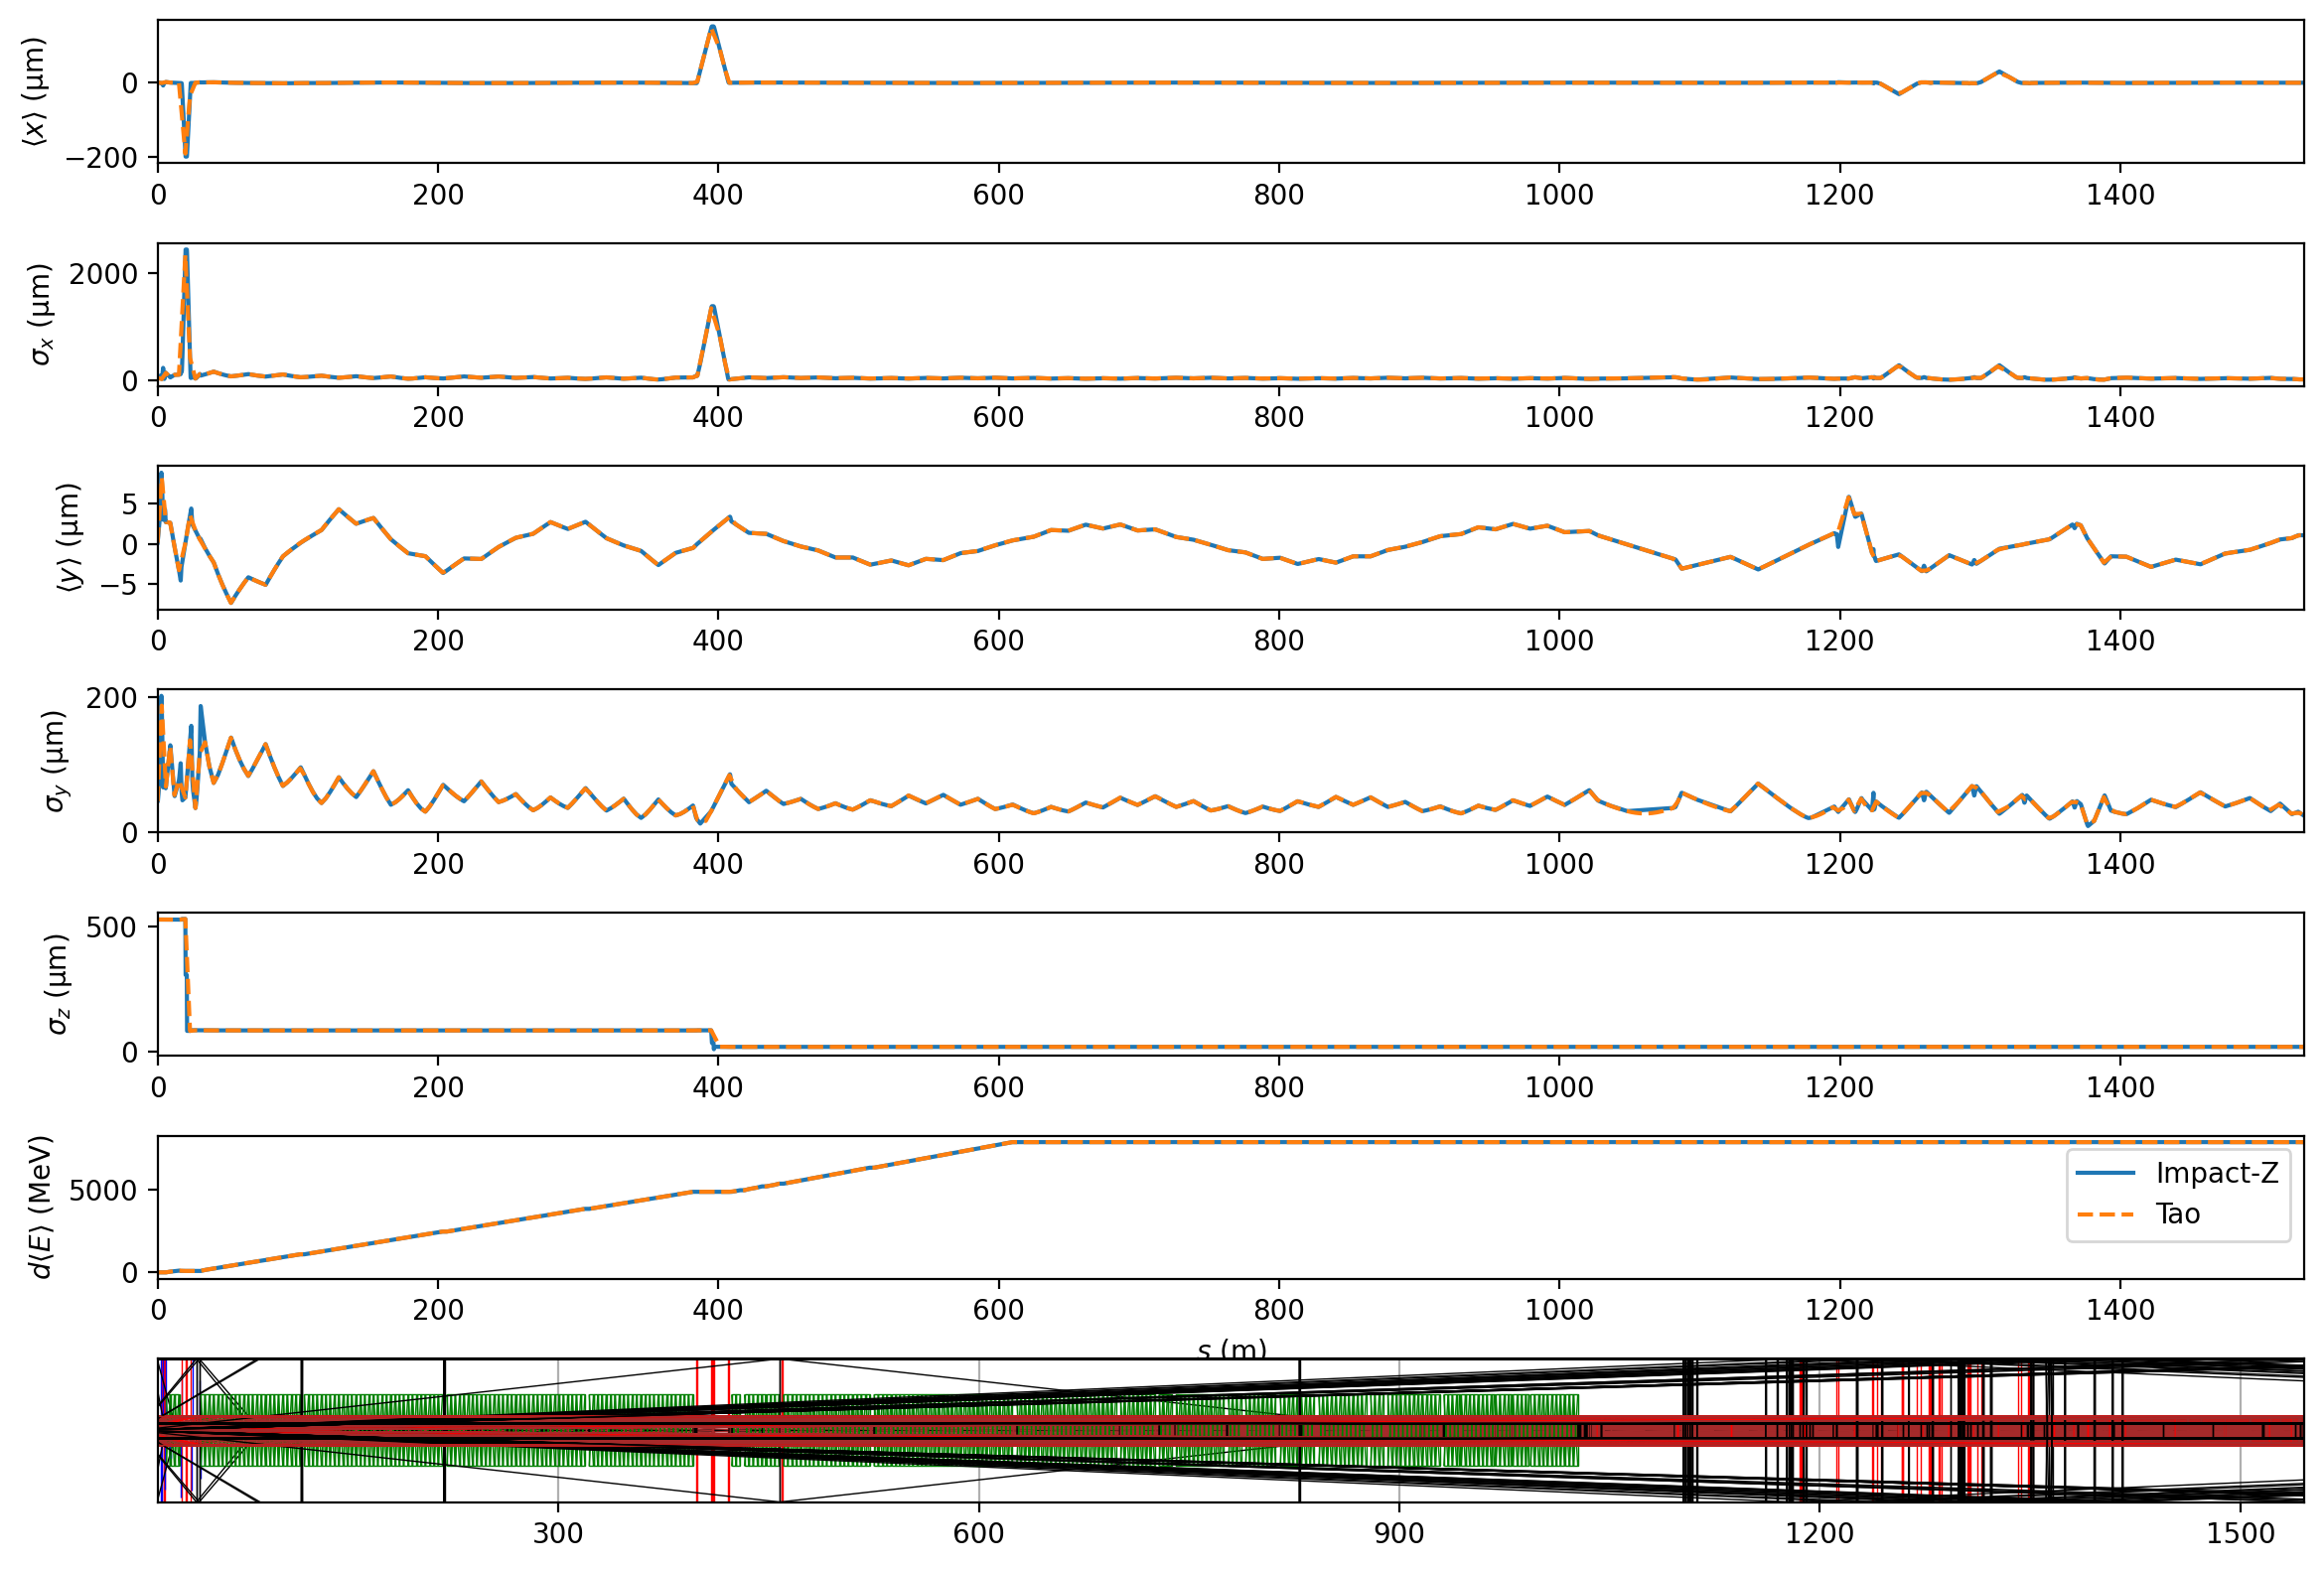

In [9]:
IZ.interfaces.bmad.plot_impactz_and_tao_stats(I, tao)

In [10]:
P2 = I.output.particles['final_particles']

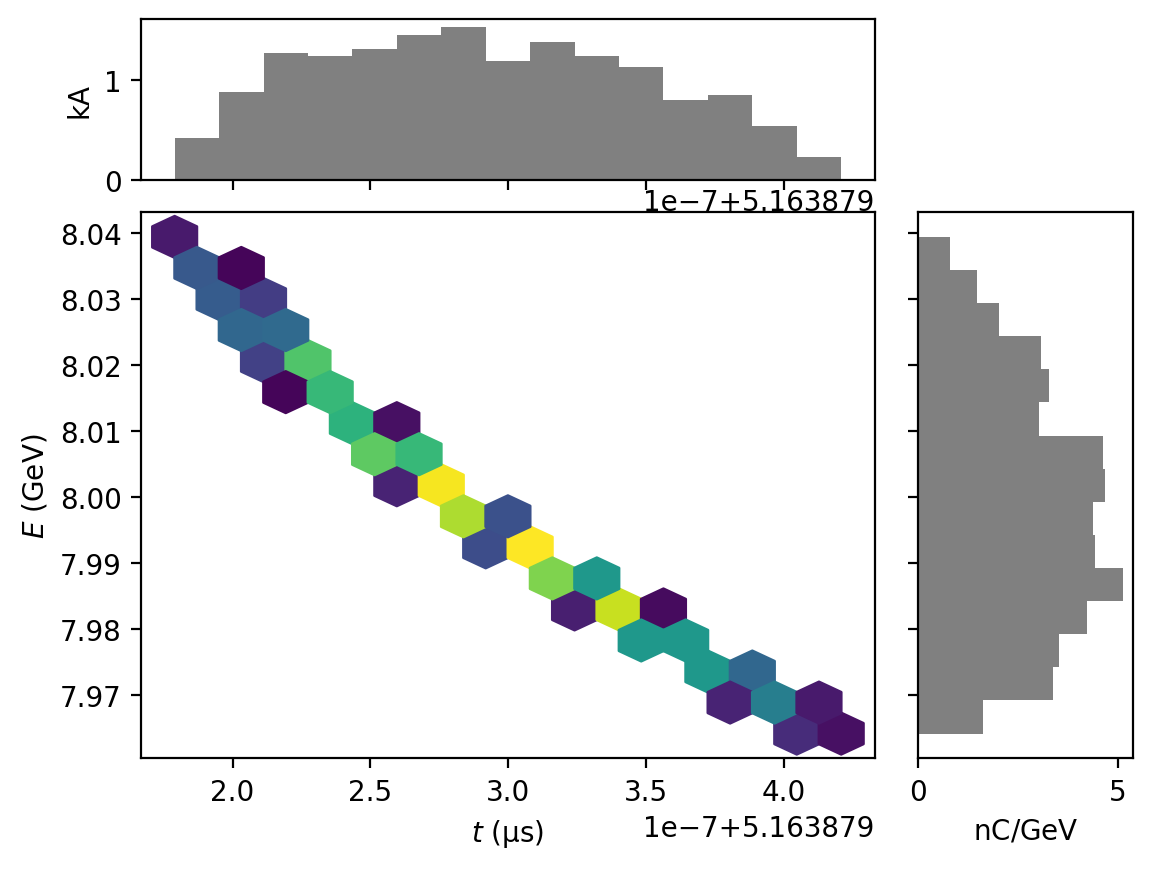

In [11]:
P2.plot('t', 'energy')

# Compare particles

In [12]:
def compare(xkey = 'x',
            ykey = 'y',
            skip=1,
           ):
    fig, ax = plt.subplots()
    
    
    for p, label, marker in ( 
                (P1, 'Bmad', 'X'),
                (P2, 'Impact-Z', '.'),
        ):
        ax.scatter(p[xkey][::skip], p[ykey][::skip], label=label, marker=marker)
    
    plt.legend()
    
    ax.set_xlabel(xkey)
    ax.set_ylabel(ykey)

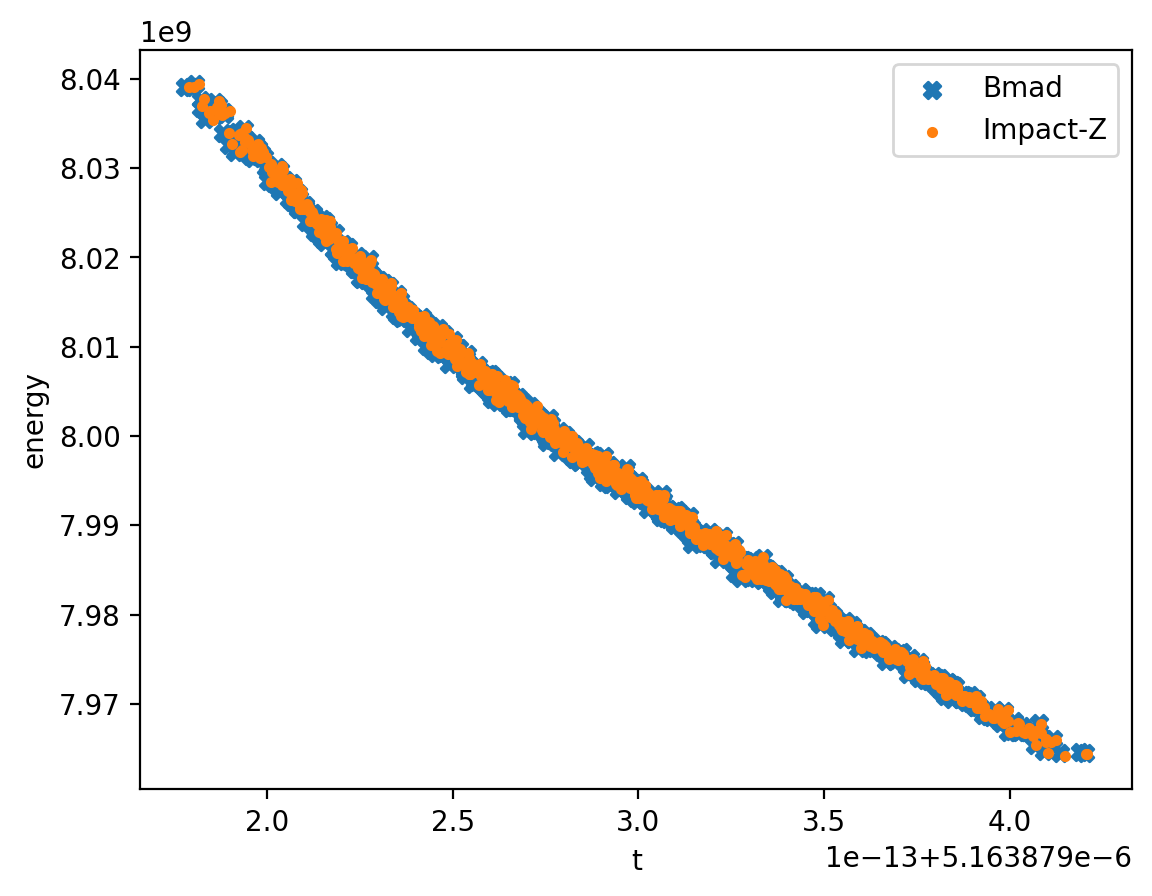

In [13]:
compare('t', 'energy')

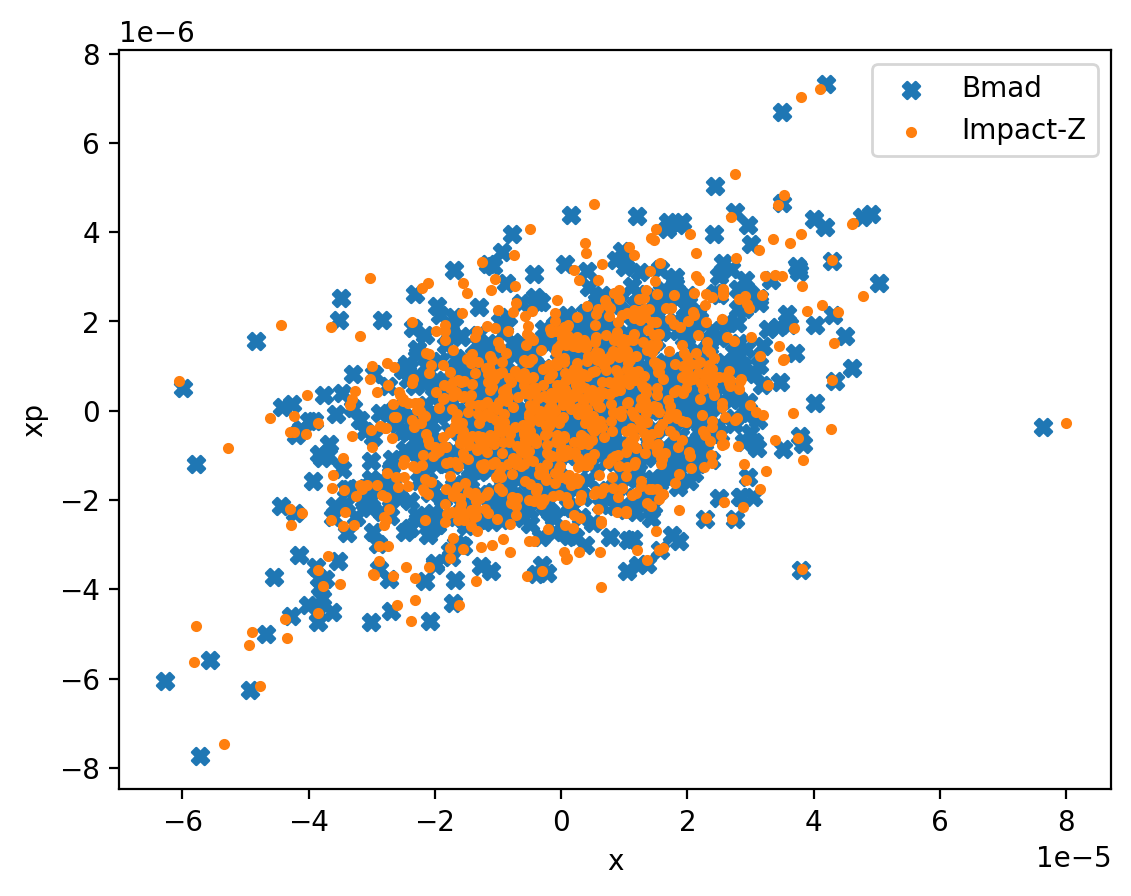

In [14]:
compare('x', 'xp')

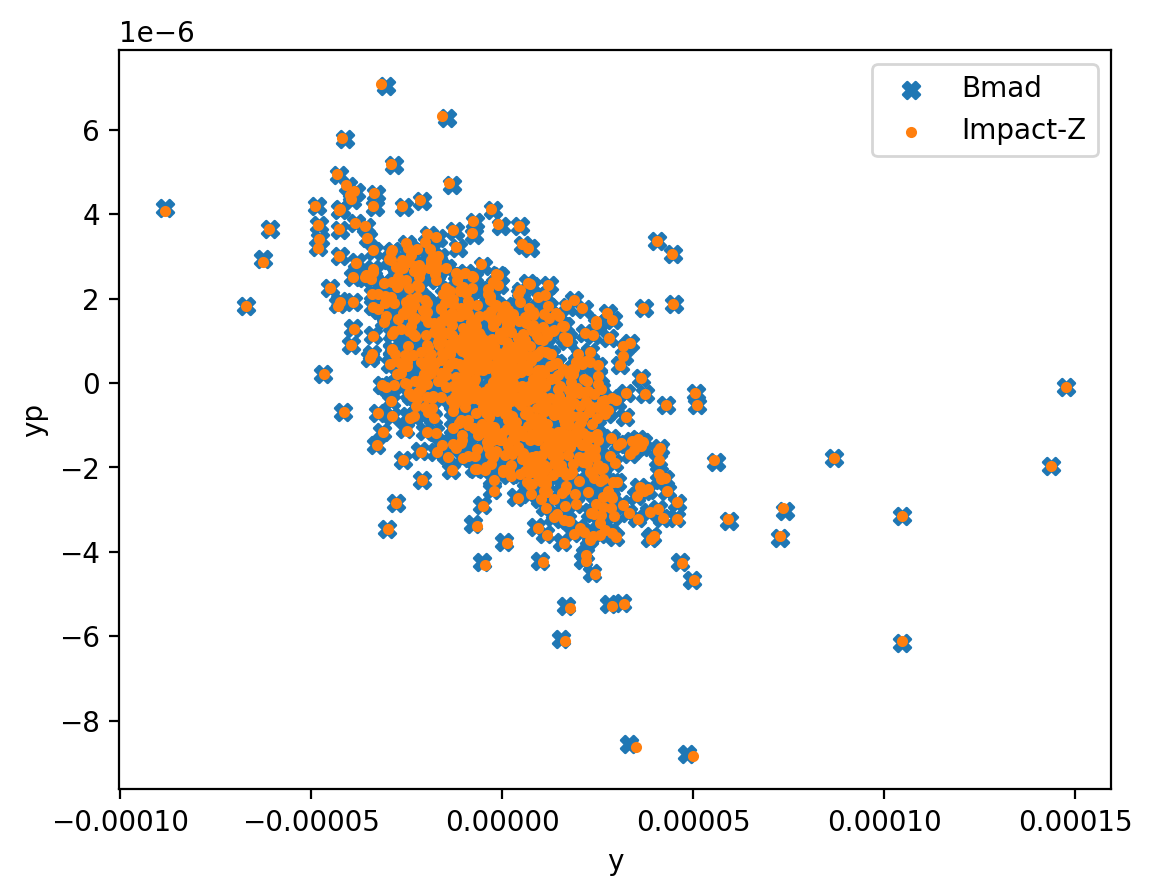

In [15]:
compare('y', 'yp')